In [2]:
#Libraries & Imports
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

ROOT = Path.cwd().resolve().parent.parent

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)

print('All libraries loaded.')

All libraries loaded.


### Data Collection and EDA Analysis
**Goal of this notebook:** Explore and review the 10-city Open-Meteo dataset for quality and assess which variables are suitable for downstream feature engineering and modelling as per the goals for this project.

This notebook aims to answer the following questions:
1. Is the data structurally sound? (shape, dtypes, date continuity)
2. Are there missing values or impossible values?
3. What do the distributions look like - skew, spread, outliers?
4. How do variables correlate with the primary target `tavg`?
5. How do cities differ climatically - are the datasets diverse enough to train a multi-city model?

#### Constants
All paths, city names, and the column-rename map are centralised here for easier and cleaner code structure across this notebook.

In [3]:
RAW_DIR = Path("../data/raw")
FIGURES_DIR = Path(r'..reports/figures')

# Filename - short city key used everywhere in code
CITY_FILES = {
    'sofia': 'open-meteo-sofia-2016-2026-42.71N23.40E555m.csv',
    'varna': 'open-meteo-varna-2016-2026-43.20N27.94E68m.csv',
    'veliko_tarnovo': 'open-meteo-tarnovo-2016-2026-43.13N25.62E226m.csv',
    'ruse': 'open-meteo-ruse-2016-2026-43.83N26.01E36m.csv',
    'kardzhali': 'open-meteo-kurdzhali-2016-2026-41.65N25.36E248m.csv',
    'pleven': 'open-meteo-pleven-2016-2026-43.41N24.56E96m.csv',
    'burgas': 'open-meteo-burgas-2016-2026-42.57N27.44E32m.csv',
    'haskovo': 'open-meteo-haskovo-2016-2026-41.93N25.51E195m.csv',
    'vidin': 'open-meteo-vidin-2016-2026-43.97N22.94E43m.csv',
    'yundola': 'open-meteo-yundola-2016-2026-42.00N23.84E1213m.csv',
}

CITY_METADATA = {
    'sofia': {'lat': 42.7065, 'lon': 23.3973, 'elev': 555, 'climate_zone': 'continental_plain'},
    'varna': {'lat': 43.2167, 'lon': 27.9167, 'elev': 68, 'climate_zone': 'coastal_maritime'},
    'veliko_tarnovo': {'lat': 43.1300, 'lon': 25.6200, 'elev': 226, 'climate_zone': 'subcontinental'},
    'ruse': {'lat': 43.8300, 'lon': 26.0100, 'elev': 36, 'climate_zone': 'danube_valley'},
    'kardzhali': {'lat': 41.6500, 'lon': 25.3600, 'elev': 248, 'climate_zone': 'continental_plain'},
    'pleven': {'lat': 43.4100, 'lon': 24.5600, 'elev': 96, 'climate_zone': 'continental_plain'},
    'burgas': {'lat': 42.5659, 'lon': 27.4374, 'elev': 32, 'climate_zone': 'coastal_maritime'},
    'haskovo': {'lat': 41.9300, 'lon': 25.5100, 'elev': 195, 'climate_zone': 'continental_plain'},
    'vidin': {'lat': 43.9700, 'lon': 22.9400, 'elev': 43, 'climate_zone': 'danube_valley'},
    'yundola': {'lat': 42.0035, 'lon': 23.8428, 'elev': 1213, 'climate_zone': 'alpine'},
}

# Raw Open-Meteo header short name. Encoding artefacts in the raw headers (°C shown as В°C) are handled by reading with encoding='utf-8' and matching on the normalised name.
COLUMN_RENAME = {
    'temperature_2m_mean (°C)':               'tavg',
    'temperature_2m_max (°C)':                'tmax',
    'temperature_2m_min (°C)':                'tmin',
    'precipitation_sum (mm)':                 'prcp',
    'rain_sum (mm)':                          'rain',
    'snowfall_sum (cm)':                      'snow',
    'snowfall_water_equivalent_sum (mm)':     'snow_weq',
    'wind_speed_10m_max (km/h)':              'wspd_max',
    'wind_speed_10m_mean (km/h)':             'wspd',
    'wind_speed_10m_min (km/h)':              'wspd_min',
    'wind_gusts_10m_max (km/h)':              'wgust_max',
    'wind_gusts_10m_mean (km/h)':             'wgust',
    'wind_gusts_10m_min (km/h)':              'wgust_min',
    'wind_direction_10m_dominant (°)':        'wdir',
    'cloud_cover_max (%)':                    'cloud_max',
    'cloud_cover_min (%)':                    'cloud_min',
    'cloud_cover_mean (%)':                   'cloud',
    'relative_humidity_2m_max (%)':           'rh_max',
    'relative_humidity_2m_min (%)':           'rh_min',
    'relative_humidity_2m_mean (%)':          'rh',
    'dew_point_2m_max (°C)':                  'dewpt_max',
    'dew_point_2m_min (°C)':                  'dewpt_min',
    'dew_point_2m_mean (°C)':                 'dewpt',
    'pressure_msl_max (hPa)':                 'pres_max',
    'pressure_msl_min (hPa)':                 'pres_min',
    'pressure_msl_mean (hPa)':                'pres',
    'surface_pressure_max (hPa)':             'surf_pres_max',
    'surface_pressure_min (hPa)':             'surf_pres_min',
    'surface_pressure_mean (hPa)':            'surf_pres',
    'vapour_pressure_deficit_max (kPa)':      'vpd_max',
    'soil_moisture_0_to_100cm_mean (m³/m³)':  'soil_moist',
    'soil_temperature_0_to_100cm_mean (°C)':  'soil_temp',
}

# Train / val / test boundaries
TRAIN_END   = '2023-12-31'
VAL_END     = '2024-12-31'
TEST_END    = '2026-05-01'

# ARGUMENTATION: Weather data is a time series and each day is correlated with the days around it. A random split might destroys this in a way that makes the model look far better than it actually is. 
# With a date-based split the model will only see past data when predicting future data, which reflects the real forecasting situation.

print('Constants defined.')

Constants defined.


Before proceeding with the data loading here is a table with definition of each parameter present in this dataset as per Open-Meteo documentation:

### Parameter Reference Table
 
| Column (raw name) | Short name | Unit | Description | Aggregation method |
|---|---|---|---|---|
| `temperature_2m_mean (°C)` | `tavg` | °C | Air temperature at 2 metres above ground | Daily mean of hourly instantaneous values |
| `temperature_2m_max (°C)` | `tmax` | °C | Air temperature at 2 metres above ground | Daily maximum of hourly instantaneous values |
| `temperature_2m_min (°C)` | `tmin` | °C | Air temperature at 2 metres above ground | Daily minimum of hourly instantaneous values |
| `precipitation_sum (mm)` | `prcp` | mm | Total precipitation -rain, showers and snow -sum of preceding-hour values | Daily sum |
| `rain_sum (mm)` | `rain` | mm | Liquid precipitation only, excluding snowfall | Daily sum |
| `snowfall_sum (cm)` | `snow` | cm | Snowfall amount in centimetres (water equivalent ÷ 7) | Daily sum |
| `snowfall_water_equivalent_sum (mm)` | `snow_weq` | mm | Snowfall converted to liquid water equivalent (snow cm × 7 ≈ mm) | Daily sum |
| `wind_speed_10m_max (km/h)` | `wspd_max` | km/h | Wind speed at 10 metres above ground | Daily maximum of hourly instantaneous values |
| `wind_speed_10m_mean (km/h)` | `wspd` | km/h | Wind speed at 10 metres above ground | Daily mean of hourly instantaneous values |
| `wind_speed_10m_min (km/h)` | `wspd_min` | km/h | Wind speed at 10 metres above ground | Daily minimum of hourly instantaneous values |
| `wind_gusts_10m_max (km/h)` | `wgust_max` | km/h | Wind gusts at 10 metres -maximum wind gust of each preceding hour | Daily maximum |
| `wind_gusts_10m_mean (km/h)` | `wgust` | km/h | Wind gusts at 10 metres -maximum wind gust of each preceding hour | Daily mean |
| `wind_gusts_10m_min (km/h)` | `wgust_min` | km/h | Wind gusts at 10 metres -maximum wind gust of each preceding hour | Daily minimum |
| `wind_direction_10m_dominant (°)` | `wdir` | ° | Dominant wind direction at 10 metres | Most frequent direction over the day |
| `cloud_cover_max (%)` | `cloud_max` | % | Total cloud cover as area fraction | Daily maximum of hourly instantaneous values |
| `cloud_cover_min (%)` | `cloud_min` | % | Total cloud cover as area fraction | Daily minimum of hourly instantaneous values |
| `cloud_cover_mean (%)` | `cloud` | % | Total cloud cover as area fraction | Daily mean of hourly instantaneous values |
| `relative_humidity_2m_max (%)` | `rh_max` | % | Relative humidity at 2 metres above ground | Daily maximum of hourly instantaneous values |
| `relative_humidity_2m_min (%)` | `rh_min` | % | Relative humidity at 2 metres above ground | Daily minimum of hourly instantaneous values |
| `relative_humidity_2m_mean (%)` | `rh` | % | Relative humidity at 2 metres above ground | Daily mean of hourly instantaneous values |
| `dew_point_2m_max (°C)` | `dewpt_max` | °C | Dew point temperature at 2 metres above ground | Daily maximum of hourly instantaneous values |
| `dew_point_2m_min (°C)` | `dewpt_min` | °C | Dew point temperature at 2 metres above ground | Daily minimum of hourly instantaneous values |
| `dew_point_2m_mean (°C)` | `dewpt` | °C | Dew point temperature at 2 metres above ground | Daily mean of hourly instantaneous values |
| `pressure_msl_max (hPa)` | `pres_max` | hPa | Atmospheric pressure reduced to mean sea level -standard meteorological pressure, comparable across all elevations | Daily maximum of hourly instantaneous values |
| `pressure_msl_min (hPa)` | `pres_min` | hPa | Atmospheric pressure reduced to mean sea level | Daily minimum of hourly instantaneous values |
| `pressure_msl_mean (hPa)` | `pres` | hPa | Atmospheric pressure reduced to mean sea level | Daily mean of hourly instantaneous values |
| `surface_pressure_max (hPa)` | `surf_pres_max` | hPa | Pressure at actual surface elevation -decreases with altitude, unlike MSL pressure | Daily maximum of hourly instantaneous values |
| `surface_pressure_min (hPa)` | `surf_pres_min` | hPa | Pressure at actual surface elevation | Daily minimum of hourly instantaneous values |
| `surface_pressure_mean (hPa)` | `surf_pres` | hPa | Pressure at actual surface elevation | Daily mean of hourly instantaneous values |
| `vapour_pressure_deficit_max (kPa)` | `vpd_max` | kPa | Difference between saturation and actual vapour pressure. VPD >1.6 kPa increases plant water stress; VPD <0.4 kPa suppresses transpiration | Daily maximum of hourly instantaneous values |
| `soil_moisture_0_to_100cm_mean (m³/m³)` | `soil_moist` | m³/m³ | Volumetric soil water content -aggregated from 0–7, 7–28 and 28–100 cm layer measurements | Daily mean |
| `soil_temperature_0_to_100cm_mean (°C)` | `soil_temp` | °C | Average soil temperature -aggregated from 0–7, 7–28 and 28–100 cm layer measurements | Daily mean |


### Timezone
All timestamps are in `Europe/Moscow` time (UTC+2 / UTC+3 DST), corresponding to `utc_offset_seconds: 7200 / 10800`.

### Data Loading and Exploration
Each Open-Meteo CSV has two metadata rows (lat/lon/elevation, then a blank line) before the column header row. Using `skiprows=3` skips those three rows and puts the column header on row 0.

`open-meteo-haskovo-2016-2026-41.93N25.51E195m.csv` Haskovo has `wind_direction_10m_dominant` as the last column instead of the 3rd-to-last like all the other datasets. Renaming via a dictionary keyed on column names will ensure column access by name, rather than position.

Additional challenge is that Open-Meteo exports UTF-8. The degree symbol `°` is multi-byte in UTF-8; reading with `encoding='utf-8'` ensures the column names parse correctly so the rename map above matches.

In [4]:
def load_city(city_key: str, filename: str) -> pd.DataFrame:

# Load one Open-Meteo CSV, apply column rename, parse the date index.
    path = RAW_DIR / filename
    df = pd.read_csv(
        path,
        skiprows=3,
        parse_dates=['time'],
        index_col='time',
        encoding='utf-8',
    )
# Only renaming columns that exist (handles Haskovo column order issue as well)
    rename_map = {k: v for k, v in COLUMN_RENAME.items() if k in df.columns}
    df = df.rename(columns=rename_map)
    df['city'] = city_key
    return df


city_dfs: dict[str, pd.DataFrame] = {}
for city, fname in CITY_FILES.items():
    city_dfs[city] = load_city(city, fname)
    print(f' {city:20s}  shape={city_dfs[city].shape} /'
          f' {city_dfs[city].index.min().date()} - {city_dfs[city].index.max().date()}')

print(f'\nTotal cities loaded: {len(city_dfs)}')

 sofia                 shape=(3774, 33) / 2016-01-01 - 2026-05-01
 varna                 shape=(3774, 33) / 2016-01-01 - 2026-05-01
 veliko_tarnovo        shape=(3774, 33) / 2016-01-01 - 2026-05-01
 ruse                  shape=(3774, 33) / 2016-01-01 - 2026-05-01
 kardzhali             shape=(3774, 33) / 2016-01-01 - 2026-05-01
 pleven                shape=(3774, 33) / 2016-01-01 - 2026-05-01
 burgas                shape=(3774, 33) / 2016-01-01 - 2026-05-01
 haskovo               shape=(3774, 33) / 2016-01-01 - 2026-05-01
 vidin                 shape=(3774, 33) / 2016-01-01 - 2026-05-01
 yundola               shape=(3774, 33) / 2016-01-01 - 2026-05-01

Total cities loaded: 10


In [27]:
pd.set_option('display.max_columns', None)

for city, df in city_dfs.items():
    print(f'{city.upper()}:')
    display(df.head())
    print()

SOFIA:


,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,wdir,tmax,tmin,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-5.7,0.0,0.0,0.00,8.7,23.8,100,0,18,-16.4,-15.4,-18.3,45,60,24,0.0,1029.6,1034.7,1025.4,959.6,963.5,956.0,15.2,5.1,5.4,0.5,0.46,0.31,2.9,241,-0.1,-9.6,sofia
2016-01-02,-2.6,0.1,0.0,0.28,7.3,18.4,100,58,83,-10.2,-7.3,-15.7,56,74,41,0.4,1025.4,1027.4,1023.6,956.5,958.3,954.8,15.2,4.3,11.2,1.8,0.31,0.31,2.8,303,0.8,-4.6,sofia
2016-01-03,-4.9,11.3,0.0,7.98,12.4,31.0,100,97,100,-8.2,-7.1,-11.8,78,86,71,11.4,1019.1,1023.6,1015.0,950.0,954.8,945.3,24.6,9.7,16.6,7.3,0.15,0.31,2.7,63,-2.6,-9.6,sofia
2016-01-04,-5.7,8.0,0.0,5.74,8.4,42.5,100,71,95,-7.7,-1.4,-12.9,86,95,76,8.2,1009.7,1016.2,1001.2,941.0,945.7,934.2,17.9,5.5,9.7,3.3,0.14,0.31,2.6,93,1.0,-11.4,sofia
2016-01-05,1.9,3.2,0.4,1.96,8.4,47.5,100,18,74,-0.4,2.3,-3.4,85,93,69,2.8,1002.8,1006.3,999.1,936.4,939.8,932.1,22.0,5.4,11.9,2.6,0.33,0.31,2.5,208,7.6,-2.4,sofia



VARNA:


,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,wdir,tmax,tmin,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-3.2,0.0,0.0,0.00,18.4,34.9,2,0,0,-10.3,-8.7,-11.6,59,70,44,0.0,1027.8,1030.5,1025.9,1019.0,1021.6,1017.2,27.3,13.8,11.5,6.3,0.34,0.243,6.1,317,-0.2,-5.2,varna
2016-01-02,-5.3,0.0,0.0,0.00,15.8,33.5,51,0,9,-12.1,-9.9,-13.4,59,71,49,0.0,1028.4,1029.6,1027.1,1019.6,1020.7,1018.2,23.3,12.8,16.6,10.0,0.25,0.243,5.5,352,-2.9,-7.2,varna
2016-01-03,-5.3,6.1,0.0,4.34,18.6,39.6,100,0,80,-10.2,-2.6,-14.2,69,84,62,6.2,1024.6,1029.5,1015.4,1015.8,1020.5,1006.8,27.4,14.8,18.7,10.1,0.16,0.242,5.0,32,-0.2,-8.3,varna
2016-01-04,0.6,8.2,0.0,6.02,20.1,40.3,100,95,100,-1.3,-0.4,-2.2,87,93,83,8.6,1010.3,1014.6,1005.7,1001.7,1006.0,997.2,24.8,11.4,6.8,1.4,0.11,0.243,4.7,36,1.6,-0.1,varna
2016-01-05,-0.4,3.8,3.0,0.56,19.6,38.5,100,0,46,-2.4,1.9,-5.8,87,95,78,0.8,1004.4,1010.0,1000.1,995.9,1001.3,991.7,24.4,11.8,11.2,4.5,0.13,0.247,4.4,286,2.6,-4.4,varna



VELIKO_TARNOVO:


...

,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,tmax,tmin,wdir,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-4.1,0.0,0.0,0.00,9.8,15.5,10,0,1,-15.2,-11.3,-17.1,43,64,24,0.0,1028.6,1032.5,1025.2,1003.5,1007.1,1000.1,13.2,7.2,10.4,5.3,0.51,0.428,5.0,1.3,-7.3,231,haskovo
2016-01-02,-3.8,0.0,0.0,0.00,9.4,20.2,78,1,26,-10.6,-9.3,-11.8,60,76,44,0.0,1026.7,1028.6,1025.1,1001.7,1003.6,1000.0,13.4,6.4,6.1,2.9,0.33,0.428,4.7,-0.5,-6.6,79,haskovo
2016-01-03,-5.1,9.7,0.0,6.86,13.9,29.2,100,76,96,-9.4,-6.0,-12.4,73,92,59,9.8,1022.1,1027.2,1013.8,997.1,1002.0,988.8,21.6,10.4,16.2,8.3,0.17,0.428,4.4,-3.8,-6.7,56,haskovo
2016-01-04,-4.4,6.8,0.0,4.90,12.8,23.8,100,88,98,-6.0,-4.7,-7.6,89,94,83,7.0,1010.5,1013.2,1005.7,985.8,988.3,981.1,14.5,7.1,6.1,1.0,0.08,0.427,4.1,-2.8,-6.1,333,haskovo
2016-01-05,-1.8,1.9,0.4,1.05,8.2,13.7,100,5,65,-3.7,-2.4,-5.6,88,96,70,1.5,1004.8,1009.5,1001.5,980.5,985.1,977.2,9.0,4.6,4.3,1.1,0.21,0.429,3.9,2.0,-4.6,294,haskovo



VIDIN:


,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,wdir,tmax,tmin,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-3.8,0.0,0.0,0.00,10.5,19.1,99,0,18,-11.1,-8.8,-13.1,60,88,32,0.0,1028.6,1033.6,1025.2,1023.0,1028.0,1019.6,11.1,7.0,4.3,0.8,0.49,0.293,5.7,260,2.2,-8.4,vidin
2016-01-02,-5.0,0.1,0.0,0.14,15.8,29.5,100,0,43,-11.2,-9.9,-12.5,63,82,51,0.2,1028.2,1030.4,1025.6,1022.6,1024.8,1020.0,19.2,10.3,10.1,6.2,0.24,0.293,5.2,80,-2.8,-8.3,vidin
2016-01-03,-8.9,17.4,0.0,12.18,22.3,42.8,100,99,100,-13.2,-12.0,-14.4,71,86,62,17.4,1024.1,1028.1,1019.6,1018.5,1022.5,1013.9,35.0,18.3,22.0,11.9,0.15,0.293,4.7,85,-5.9,-11.7,vidin
2016-01-04,-11.1,4.2,0.0,3.43,12.6,20.9,100,93,99,-13.0,-11.5,-14.3,86,88,81,4.9,1013.7,1019.7,1006.7,1008.0,1014.0,1001.1,13.2,6.0,5.4,0.7,0.06,0.293,4.3,88,-9.8,-12.7,vidin
2016-01-05,-9.7,6.4,0.0,4.48,9.1,14.4,100,0,44,-12.0,-9.3,-14.1,83,89,68,6.4,1006.1,1008.6,1004.6,1000.5,1003.0,999.0,9.1,4.6,2.9,1.1,0.14,0.293,4.0,5,-4.6,-12.0,vidin



YUNDOLA:


,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,wdir,tmax,tmin,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-8.1,0.0,0.0,0.00,8.6,25.9,100,0,14,-21.8,-18.3,-26.6,35,49,17,0.0,1028.4,1034.3,1024.5,881.5,884.6,878.7,18.0,5.8,9.0,2.9,0.43,0.373,2.0,275,-2.2,-12.1,yundola
2016-01-02,-4.7,0.0,0.0,0.00,7.2,22.3,100,13,64,-13.8,-9.5,-18.1,50,68,40,0.0,1024.2,1026.0,1022.9,879.6,881.4,878.4,18.4,4.9,13.3,3.3,0.30,0.373,1.9,294,-1.7,-7.2,yundola
2016-01-03,-4.0,8.4,0.0,5.88,8.3,33.8,100,77,96,-6.5,-3.5,-9.2,83,97,70,8.4,1016.7,1022.9,1011.0,873.6,878.6,867.3,22.3,5.5,10.1,2.6,0.13,0.372,1.8,185,-1.6,-6.8,yundola
2016-01-04,-3.2,5.3,0.0,3.78,11.2,42.5,100,71,95,-5.1,-1.6,-8.8,87,95,75,5.4,1006.5,1011.0,1002.3,865.1,867.1,862.2,20.8,6.2,11.5,1.5,0.16,0.372,1.7,227,1.2,-7.4,yundola
2016-01-05,0.9,3.9,0.0,2.73,12.3,59.0,100,11,76,-1.4,0.3,-3.0,85,93,64,3.9,1002.2,1006.7,999.2,863.4,866.4,859.7,34.6,9.3,18.4,4.1,0.31,0.372,1.7,246,4.8,-1.8,yundola


I will now look further into the data structure by verifying the following:
- Every city has the same column set after renaming (no silent column drift)
- The date range is exactly from 2016-01-01 to 2026-05-01 with no gaps
- All dtypes are numeric (float64) - no strings hiding in numeric columns

This step is necessary as the model that will be built later on will rely on consecutive daily steps, a single missing date could result in more challenges when feature engineering. 

In [6]:
print('Column consistency across cities:')
ref_cols = sorted([c for c in city_dfs['sofia'].columns if c != 'city'])

all_match = True
for city, df in city_dfs.items():
    city_cols = sorted([c for c in df.columns if c != 'city'])
    if city_cols != ref_cols:
        missing = set(ref_cols) - set(city_cols)
        extra   = set(city_cols) - set(ref_cols)
        print(f'  MISMATCH {city}: missing={missing}  extra={extra}')
        all_match = False
if all_match:
    print(f'  All {len(city_dfs)} cities share the same {len(ref_cols)} columns')

print('\nDate range & continuity check:')
expected_freq = pd.tseries.frequencies.to_offset('D')
for city, df in city_dfs.items():
    idx = df.index
    full_range = pd.date_range(idx.min(), idx.max(), freq='D')
    gaps = full_range.difference(idx)
    status = 'OK' if len(gaps) == 0 else f'GAPS: {gaps.tolist()}'
    print(f' {city:20s}  rows ={len(df):5d}  {idx.min().date()} - {idx.max().date()}  {status}')

print('\nDtype audit (should all be float64 or int64):')
type_issues = []
for city, df in city_dfs.items():
    bad = [c for c in df.columns if c != 'city' and df[c].dtype == object]
    if bad:
        type_issues.append((city, bad))
if type_issues:
    for city, cols in type_issues:
        print(f'  {city}: object dtype in {cols}')
else:
    print('All numeric columns are numeric')

Column consistency across cities:
  All 10 cities share the same 32 columns

Date range & continuity check:
 sofia                 rows = 3774  2016-01-01 - 2026-05-01  OK
 varna                 rows = 3774  2016-01-01 - 2026-05-01  OK
 veliko_tarnovo        rows = 3774  2016-01-01 - 2026-05-01  OK
 ruse                  rows = 3774  2016-01-01 - 2026-05-01  OK
 kardzhali             rows = 3774  2016-01-01 - 2026-05-01  OK
 pleven                rows = 3774  2016-01-01 - 2026-05-01  OK
 burgas                rows = 3774  2016-01-01 - 2026-05-01  OK
 haskovo               rows = 3774  2016-01-01 - 2026-05-01  OK
 vidin                 rows = 3774  2016-01-01 - 2026-05-01  OK
 yundola               rows = 3774  2016-01-01 - 2026-05-01  OK

Dtype audit (should all be float64 or int64):
All numeric columns are numeric


Since Open-Meteo is provides gap-free and consistent historical weather data using weather reanalysis from ERA5 (0.25°, from 1940) and ERA5-Land (0.1°, from 1950) and ECMWF IFS (9 km, from 2017), I expect 0 missing values, however I would still like to verify this for the following reasons:
- Any NaN that slips through would propagate into every lag/rolling feature derived from it.
- If NaNs exist I need to decide *before* feature engineering whether to impute or drop and to fit any imputer on the training set only to avoid leakage.

In [37]:
print('Missing value counts per city:')
any_missing = False
for city, df in city_dfs.items():
    numeric_cols = [c for c in df.columns if c != 'city']
    null_counts = df[numeric_cols].isnull().sum()
    total_nulls = null_counts.sum()
    if total_nulls > 0:
        print(f'{city}: {total_nulls} nulls found!')
        print(null_counts[null_counts > 0].to_string())
        any_missing = True
    else:
        print(f'{city:20s}: 0 missing values')

if not any_missing:
    print('\nConclusion: dataset is complete. No missing values present.')

Missing value counts per city:
sofia               : 0 missing values
varna               : 0 missing values
veliko_tarnovo      : 0 missing values
ruse                : 0 missing values
kardzhali           : 0 missing values
pleven              : 0 missing values
burgas              : 0 missing values
haskovo             : 0 missing values
vidin               : 0 missing values
yundola             : 0 missing values

Conclusion: dataset is complete. No missing values present.


### Descriptive Statistics
Before engineering features or building models, I need to understand the statistical landscape across all cities. Comparing mean, std, min, max per city reveals:
- **Climatic diversity**: Do cities differ enough to justify a multi-city model vs. city-specific models?
- **Range of values**: What scales will the model encounter? (informs scaling strategy)
- **Seasonal extent**: How wide is the interquartile range? High spread suggests strong seasonality.

This step answers: *Can a single model generalise across all 10 cities, or are the selected cities too different?*

### Variable Selection Rationale

The 15 variables below were chosen by combining meteorological domain knowledge with ML feature-selection practice [1, 2, 3]. Selection followed three criteria:

**1. Direct relevance to forecast targets**:
`tavg`, `tmax`, `tmin` (regression targets), `prcp`, `rain` (classification 
targets), and `snow` (winter-regime proxy affecting both tasks).

**2. Core synoptic signal** - variables mandated by the WMO as standard surface observations for numerical weather prediction [1]:
- `pres` - mean sea-level pressure: the primary synoptic driver. Pressure gradients govern air mass movements and regime transitions at the day-to-week scale.
- `cloud`, `rh`, `dewpt` - direct moisture-energy couplings: cloud cover modulates the diurnal temperature(the mathematical difference between the highest and lowest temperatures recorded within a 24-hour period) range; relative humidity and dew point determine precipitation likelihood and fog/frost risk.
- `wdir` - dominant wind direction: encodes air mass origin (warm maritime vs. cold continental advection), a key regime classifier. Advection is the horizontal transport of any atmospheric property by the wind.
- `wspd`, `wgust_max` - wind magnitude and convective gusts.

**3. Medium-range boundary conditions** - variables with documented lagged predictive skill beyond 3 days [2]:
- `soil_moist` - soil moisture memory persists 5–16 days and modulates evapotranspiration, near-surface temperature, and convective potential.
- `vpd_max` - vapour pressure deficit: a compound heat-and-dryness indicator with skill for extreme temperature days in the warm season.

### Variable Selection Table

| Variable | Role | Forecast task |
|---|---|---|
| `tavg`, `tmax`, `tmin` | Targets / diurnal proxies | Temperature regression |
| `prcp`, `rain` | Targets / target proxy | Rain classification |
| `snow` | Winter-regime proxy | Both |
| `pres` | Synoptic pressure driver [1] | Both |
| `cloud`, `rh`, `dewpt` | Moisture-energy couplings [1] | Both |
| `wdir` | Air mass advection regime [1] | Temperature |
| `wspd`, `wgust_max` | Wind advection & convection [1] | Both |
| `soil_moist` | Lagged boundary condition (5–16 day memory) [2] | Medium-range |
| `vpd_max` | Compound heat/drought signal [2] | Temperature (summer) |

Redundant variables at this stage (`surf_pres`, `pres_max/min`, `rh_max/min`, `cloud_max/min`, `dewpt_max/min`, `wspd_min`, `wgust/min`, `snow_weq`, `soil_temp`) are retained in the dataset but will be filtered in the next steps in this project via correlation analysis and VIF(variance inflation factor) to resolve potential multicollinearity [3].

In [7]:
KEY_VARS = ['tavg', 'tmax', 'tmin', 'prcp', 'rain', 'snow', 'pres', 'cloud', 'rh', 'dewpt', 'vpd_max', 'soil_moist', 'soil_temp', 'wspd', 'wgust_max']

stats_rows = []
for city, df in city_dfs.items():
    row = {'city': city}
    for var in KEY_VARS:
        s = df[var]
        row[f'{var}_mean'] = round(s.mean(), 2)
        row[f'{var}_std'] = round(s.std(), 2)
        row[f'{var}_min'] = round(s.min(), 2)
        row[f'{var}_max'] = round(s.max(), 2)
    stats_rows.append(row)

stats_df = pd.DataFrame(stats_rows).set_index('city')

# Display temperature sub-table
temp_cols = [c for c in stats_df.columns if c.startswith(('tavg', 'tmax', 'tmin'))]
print('Temperature statistics (°C):')
display(stats_df[temp_cols])

# Display precipitation sub-table
prcp_cols = [c for c in stats_df.columns if c.startswith(('prcp', 'rain', 'snow'))]
print('\nPrecipitation statistics (mm / cm):')
display(stats_df[prcp_cols])

# Display atmospheric predictor sub-table
atm_cols = [c for c in stats_df.columns if c.startswith(('pres', 'cloud', 'rh', 'dewpt', 'vpd'))]
print('\nAtmospheric predictor statistics:')
display(stats_df[atm_cols])

Temperature statistics (°C):


,tavg_mean,tavg_std,tavg_min,tavg_max,tmax_mean,tmax_std,tmax_min,tmax_max,tmin_mean,tmin_std,tmin_min,tmin_max
city,,,,,,,,,,,,
sofia,11.45,8.41,-15.0,29.9,16.95,9.20,-12.4,38.1,6.70,7.65,-18.4,23.5
varna,13.50,7.98,-11.6,30.2,17.40,8.40,-10.1,36.0,10.13,7.63,-13.6,26.7
veliko_tarnovo,12.96,8.68,-14.4,32.3,18.17,9.49,-12.2,40.7,8.23,7.91,-20.9,26.0
ruse,13.26,9.13,-14.2,32.7,18.19,9.98,-10.6,40.5,8.84,8.24,-18.8,26.9
kardzhali,13.95,8.21,-10.3,31.7,19.15,8.92,-7.7,39.3,9.20,7.52,-16.6,24.9
pleven,13.12,9.03,-13.5,32.4,18.07,9.83,-12.8,41.5,8.65,8.16,-16.8,25.5
burgas,14.00,7.98,-9.9,31.1,18.62,8.45,-7.3,40.8,9.98,7.60,-14.6,25.8
haskovo,14.01,8.69,-10.6,33.2,19.35,9.48,-8.8,40.8,9.20,7.89,-16.2,26.9
vidin,13.67,9.15,-14.0,33.7,18.55,10.08,-10.9,43.3,9.30,8.27,-19.2,26.2



Precipitation statistics (mm / cm):


,prcp_mean,prcp_std,prcp_min,prcp_max,rain_mean,rain_std,rain_min,rain_max,snow_mean,snow_std,snow_min,snow_max
city,,,,,,,,,,,,
sofia,1.81,4.27,0.0,45.4,1.58,3.96,0.0,45.4,0.17,0.95,0.0,14.42
varna,1.72,4.23,0.0,51.9,1.62,4.09,0.0,51.9,0.06,0.53,0.0,9.38
veliko_tarnovo,1.94,4.51,0.0,47.1,1.66,4.02,0.0,47.1,0.20,1.30,0.0,24.78
ruse,1.80,4.62,0.0,74.7,1.59,4.31,0.0,74.7,0.15,1.10,0.0,24.08
kardzhali,2.01,5.05,0.0,74.4,1.78,4.66,0.0,74.4,0.16,1.24,0.0,34.86
pleven,1.74,4.51,0.0,95.9,1.49,4.16,0.0,95.9,0.17,1.08,0.0,19.81
burgas,1.81,4.73,0.0,95.2,1.73,4.60,0.0,95.2,0.06,0.58,0.0,11.97
haskovo,1.94,4.88,0.0,63.5,1.76,4.56,0.0,63.5,0.13,0.99,0.0,26.39
vidin,1.64,4.12,0.0,49.6,1.48,3.89,0.0,48.9,0.12,0.86,0.0,17.29



Atmospheric predictor statistics:


,pres_mean,pres_std,pres_min,pres_max,cloud_mean,cloud_std,cloud_min,cloud_max,rh_mean,rh_std,rh_min,rh_max,dewpt_mean,dewpt_std,dewpt_min,dewpt_max,vpd_max_mean,vpd_max_std,vpd_max_min,vpd_max_max
city,,,,,,,,,,,,,,,,,,,,
sofia,1017.50,7.05,992.8,1043.4,50.28,32.07,0,100,68.05,12.40,32,98,5.01,6.95,-20.5,18.3,1.29,0.96,0.06,5.86
varna,1016.70,7.12,990.9,1040.3,49.51,31.98,0,100,73.62,10.87,36,97,8.47,7.15,-16.0,23.4,1.04,0.77,0.06,4.50
veliko_tarnovo,1016.88,7.34,992.6,1042.9,50.17,32.71,0,100,70.09,13.56,31,99,6.88,6.93,-17.3,20.7,1.34,1.03,0.01,6.30
ruse,1016.85,7.48,992.1,1043.0,51.08,32.37,0,100,70.58,14.15,30,99,7.23,7.06,-16.3,21.4,1.36,1.10,0.02,6.19
kardzhali,1016.73,6.97,990.3,1040.7,47.51,32.50,0,100,70.79,13.22,31,99,7.93,6.56,-14.8,21.0,1.40,1.06,0.02,5.95
pleven,1016.92,7.39,992.7,1042.9,49.65,32.61,0,100,68.63,14.75,29,99,6.65,6.99,-16.9,22.0,1.37,1.08,0.01,7.07
burgas,1016.65,7.05,991.0,1040.4,49.16,31.99,0,100,73.96,10.03,36,97,8.93,7.05,-15.4,23.2,1.20,0.85,0.05,6.12
haskovo,1016.60,7.14,990.1,1040.8,47.27,32.32,0,100,67.32,14.66,28,99,7.13,6.53,-15.4,20.5,1.54,1.21,0.02,6.63
vidin,1017.03,7.40,992.9,1042.8,50.83,32.69,0,100,68.79,14.19,28,99,7.19,7.07,-16.8,21.6,1.45,1.18,0.02,7.73


#### Target Variable: Temperature Distribution by City

**Why KDE over histogram?** For overlapping multi-city distributions a kernel density estimate on a shared axis makes shape differences (spread, skew, modality) far easier to read than overlapping bars.[3]

**Assumptions:**
- Yundola (1213 m elevation) should have a noticeably colder and wider distribution due to alpine climate.
- Coastal cities (Varna, Burgas) should show a compressed interannual range due to the Black Sea moderates extremes.
- Multimodality would suggest the data contains fundamentally different regimes (e.g. seasons) which later will serve to motivate seasonal lag features.

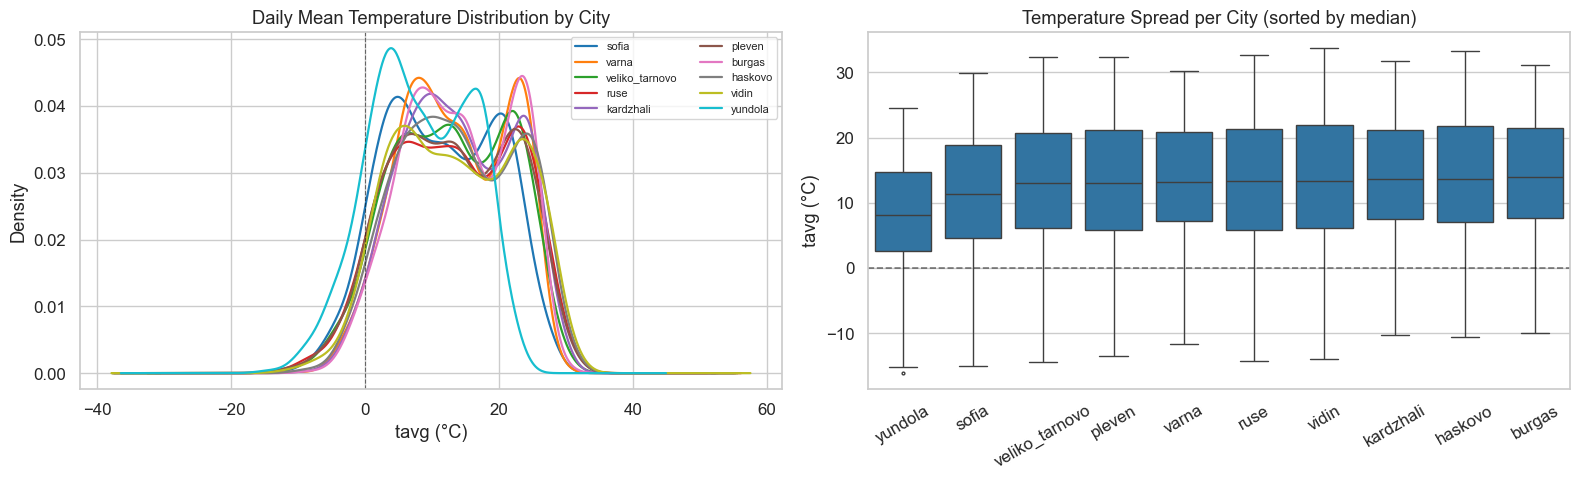

Saved: tavg_distributions.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE overlay: all cities on one axis
ax = axes[0]
for city, df in city_dfs.items():
    df['tavg'].plot.kde(ax=ax, label=city, linewidth=1.6)
ax.set_title('Daily Mean Temperature Distribution by City')
ax.set_xlabel('tavg (°C)')
ax.set_ylabel('Density')
ax.legend(fontsize=8, ncol=2)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Box plot: spread and outliers per city
ax = axes[1]
all_tavg = pd.concat(
    [df[['tavg']].assign(city=city) for city, df in city_dfs.items()]
)
city_order = all_tavg.groupby('city')['tavg'].median().sort_values().index.tolist()
sns.boxplot(data=all_tavg, x='city', y='tavg', order=city_order,
            flierprops={'markersize': 2}, ax=ax)
ax.set_title('Temperature Spread per City (sorted by median)')
ax.set_xlabel('')
ax.set_ylabel('tavg (°C)')
ax.tick_params(axis='x', rotation=30)
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)

plt.tight_layout()
#plt.savefig(FIGURES_DIR / 'tavg_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tavg_distributions.png')

#### Observations

**KDE plot (left):** All three assumptions are confirmed:
- **Yundola** (1213 m) is shifted ~ 8–10°C colder than the lowland cities and has a wider, flatter distribution reflecting the alpine climate. A mild bimodal shape (cold-winter and warm-summer modes) is visible.
- **Coastal cities (Varna, Burgas)** show compressed, slightly right-shifted distributions. The Black Sea moderates both cold extremes in winter and heat extremes in summer, producing narrower tails than their inland counterparts at similar latitude.
- **Inland cities (Ruse, Vidin, Pleven, Haskovo)** sit in the middle range with broader tails, consistent with greater continental temperature variance and no maritime buffer.

The near-zero crossing present in all distributions confirms that sub-zero temperatures occur across all cities in winter not just Yundola. Any frost-risk feature should be engineered for every city in the dataset.

**Box plot (right):** The sorted order (coldest to warmest median) makes the elevation gradient immediately readable. Yundola is an isolated outlier at the cold end. The interquartile ranges for coastal cities are visibly narrower than for inland cities at similar elevation, confirming maritime moderation beyond just a mean shift.

**Conclusion:** `elev` and `coastal` are validated as informative geographic features. A single shared temperature distribution assumption would be incorrect the multi-city model must encode geographic context explicitly.

#### Precipitation & Rain: Distribution and Zero-Inflation
Precipitation is the key variable for the binary rain-prediction task. Two properties matter to be examined here:

1. **Zero-inflation** - most days have zero precipitation. This will produce severe class imbalance in the classifier and must be quantified now.
2. **Heavy-tail skew** - on wet days, rain amounts follow a log-normal or gamma distribution. Knowing this informs whether raw `prcp` or `log(1 + prcp)` should enter regression targets.

The approach used will follow the fraction of dry days and plot the rain-day distribution separately, consistent with the two-step 'occurrence + amount' decomposition standard defined in meteorological ML [2]

In [11]:
print('Dry-day fraction (prcp == 0) per city:')
dry_stats = []
for city, df in city_dfs.items():
    n_total = len(df)
    n_dry   = (df['prcp'] == 0).sum()
    n_wet   = n_total - n_dry
    dry_pct = 100 * n_dry / n_total
    print(f'  {city:20s}  dry={n_dry:4d} ({dry_pct:.1f}%)  wet={n_wet:4d} ({100-dry_pct:.1f}%)')
    dry_stats.append({'city': city, 'dry_pct': dry_pct, 'wet_pct': 100 - dry_pct})

dry_df = pd.DataFrame(dry_stats).set_index('city').sort_values('dry_pct')

Dry-day fraction (prcp == 0) per city:
  sofia                 dry=2015 (53.4%)  wet=1759 (46.6%)
  varna                 dry=2098 (55.6%)  wet=1676 (44.4%)
  veliko_tarnovo        dry=2053 (54.4%)  wet=1721 (45.6%)
  ruse                  dry=2171 (57.5%)  wet=1603 (42.5%)
  kardzhali             dry=2060 (54.6%)  wet=1714 (45.4%)
  pleven                dry=2159 (57.2%)  wet=1615 (42.8%)
  burgas                dry=2178 (57.7%)  wet=1596 (42.3%)
  haskovo               dry=2151 (57.0%)  wet=1623 (43.0%)
  vidin                 dry=2243 (59.4%)  wet=1531 (40.6%)
  yundola               dry=1644 (43.6%)  wet=2130 (56.4%)


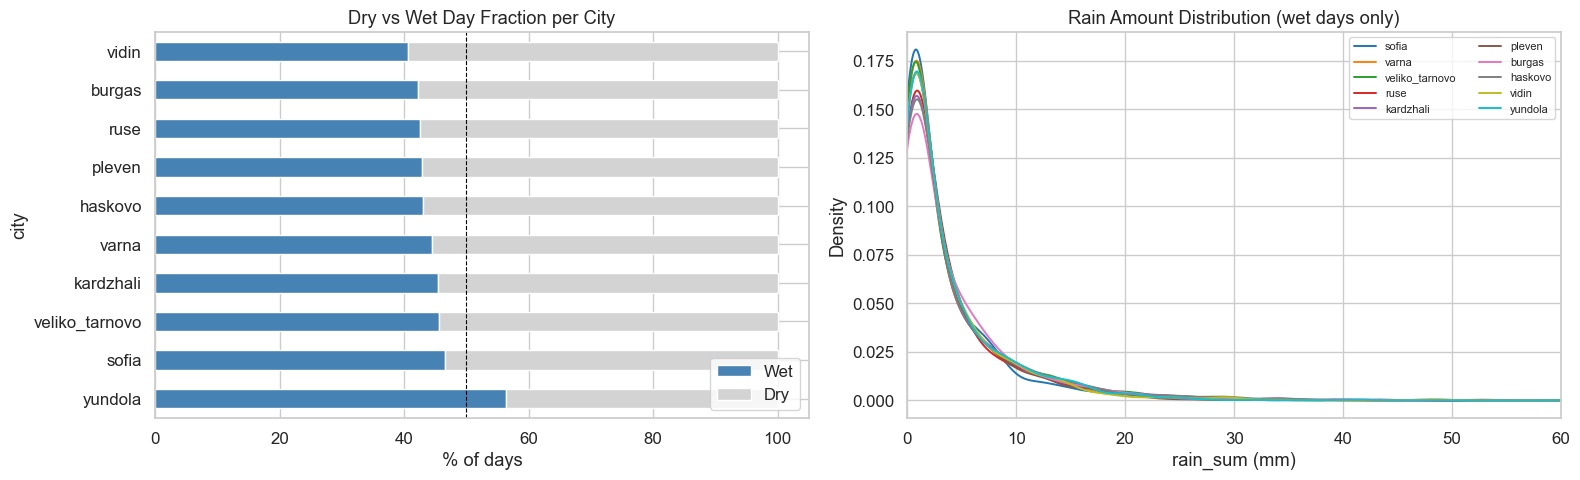

Saved: precipitation_distributions.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Dry vs wet day balance
dry_df[['wet_pct', 'dry_pct']].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=['steelblue', 'lightgray'], edgecolor='white'
)
axes[0].set_title('Dry vs Wet Day Fraction per City')
axes[0].set_xlabel('% of days')
axes[0].legend(['Wet', 'Dry'], loc='lower right')
axes[0].axvline(50, color='black', linestyle='--', linewidth=0.8)

# Rain amount distribution on wet days only (log scale to reveal tail)
ax = axes[1]
for city, df in city_dfs.items():
    wet = df.loc[df['rain'] > 0, 'rain']
    wet.plot.kde(ax=ax, label=city, linewidth=1.4)
ax.set_xlim(0, 60)
ax.set_title('Rain Amount Distribution (wet days only)')
ax.set_xlabel('rain_sum (mm)')
ax.set_ylabel('Density')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
#plt.savefig(FIGURES_DIR / 'precipitation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: precipitation_distributions.png')

#### Observations

**Dry vs wet bar chart (left):** Most cities are dry on roughly 60–65% of days, confirming the class imbalance concern raised in section 6. Key patterns:
- **Yundola** has the lowest dry-day fraction as the wettest city in the dataset, consistent with alpine precipitation caused by the Rhodope terrain.
- **Coastal cities (Varna, Burgas)** also trend wetter than the inland average, reflecting Black Sea moisture.
- **Inland continental cities (Ruse, Vidin, Pleven)** show the highest dry-day fractions, consistent with the rain-shadow effect and dry summer regimes.

**Rain-day KDE (right):** On wet days, all cities produce a strongly right-skewed distribution with the bulk of events below 15–20 mm/day and a long tail extending to 50+ mm. This shape is consistent with a log-normal or gamma distribution. The city-to-city distributions largely overlap, meaning the key inter-city difference is **frequency** of rain (dry-day fraction), not **intensity** on wet days.

**Implication for modelling:** A naive classifier predicting "no rain" every day would achieve ~60–65% accuracy with zero skill. Better approach would be to use stratified splits and class-weighting or oversampling (e.g. SMOTE) to ensure the model learns the wet-day signal, not just the majority class.

#### Seasonal Patterns

Seasonal structure is the dominant signal in weather data. This part will visualize monthly mean `tavg` and monthly total `prcp` for all cities simultaneously. This serves two purposes:

1. **Sanity check:** Does the seasonal cycle look physically reasonable? (Summer peak in July–August, winter trough in January.)
2. **Feature engineering signal:** The presence of strong seasonality justifies adding calendar features (month, day-of-year, sine/cosine encoding) and lagged rolling means.

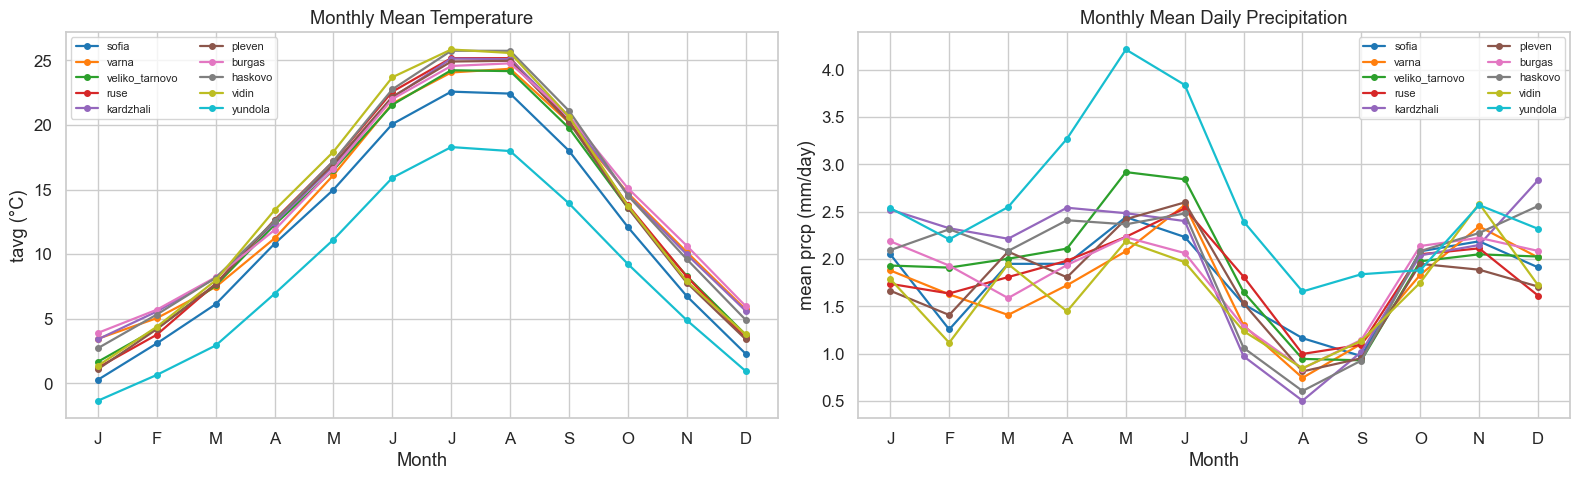

Saved: seasonal_patterns.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for city, df in city_dfs.items():
    monthly = df.groupby(df.index.month)
    axes[0].plot(range(1, 13), monthly['tavg'].mean().values,
                 marker='o', markersize=4, label=city, linewidth=1.6)
    axes[1].plot(range(1, 13), monthly['prcp'].mean().values,
                 marker='o', markersize=4, label=city, linewidth=1.6)

for ax, title, ylabel in zip(
    axes,
    ['Monthly Mean Temperature', 'Monthly Mean Daily Precipitation'],
    ['tavg (°C)', 'mean prcp (mm/day)']
):
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
#plt.savefig(FIGURES_DIR / 'seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: seasonal_patterns.png')

#### Observations

**Monthly mean temperature (left):** All cities follow the expected temperate continental cycle trough in January, peak in July/August and the sanity check passes cleanly. Notable patterns:
- Yundola is consistently coldest across all months and shows a wider seasonal amplitude than the lowland cities.
- Coastal cities (Varna, Burgas) show a slightly **delayed autumn cooling** into October compared to inland cities which is consistent with the Black Sea's thermal inertia releasing stored summer heat into autumn. This lag is a subtle but real regime difference that `coastal` alone cannot encode; a lagged sea-surface-temperature proxy could be useful.
- The ~20–25°C seasonal amplitude (January minimum to July mean) across lowland cities confirms that `sin/cos(day_of_year)` calendar features will carry the single largest share of explained variance in temperature forecasting.

**Monthly mean precipitation (right):** Precipitation seasonality is more complex and city-specific than temperature:
- Most inland cities show a **spring maximum (May-June)** from convective thunderstorm activity and a secondary autumn peak.
- Yundola has elevated precipitation across all seasons, with the highest monthly totals overall.
- Coastal cities show a more pronounced **autumn–winter secondary peak**, consistent with Mediterranean cyclone influence over the Black Sea.

The absence of a single dominant dry season means a simple binary "summer/winter" indicator would not be sufficient. Rolling precipitation sums over 7–14 days will capture the multi-month moisture memory that `soil_moist` already partially encodes.

#### Correlation with Target (`tavg`): Sofia Case Study

This section will explore Pearson correlation of all variables against `tavg` for Sofia as a representative city. This directly tells us which raw features have predictive signal *before* any lag or rolling transformation. Sofia is chosen as a representative city because it occupies the middle ground across Bulgaria's climate spectrum: at 555m elevation. This makes Sofia a typifying case for the continental inland climate that characterizes most of Bulgaria, avoiding both extreme conditions (like Yundola's alpine regime) and outlier maritime moderation (like Varna and Burgas), so its correlation patterns generalize reasonably to the broader dataset before leave-one-city-out validation in later

**Interpretation guide:**
- `|r| > 0.7` - strong linear signal; likely direct candidate for inclusion.
- `0.4 < |r| < 0.7` - moderate signal; worth engineering lags of.
- `|r| < 0.2` - weak direct linear signal; may still be useful via non-linear interactions or as lag features.

**Caveat:** Pearson r captures only linear relationships. `wdir` (circular variable 0–360°) will show near-zero r even if it carries information it needs sine/cosine decomposition first.

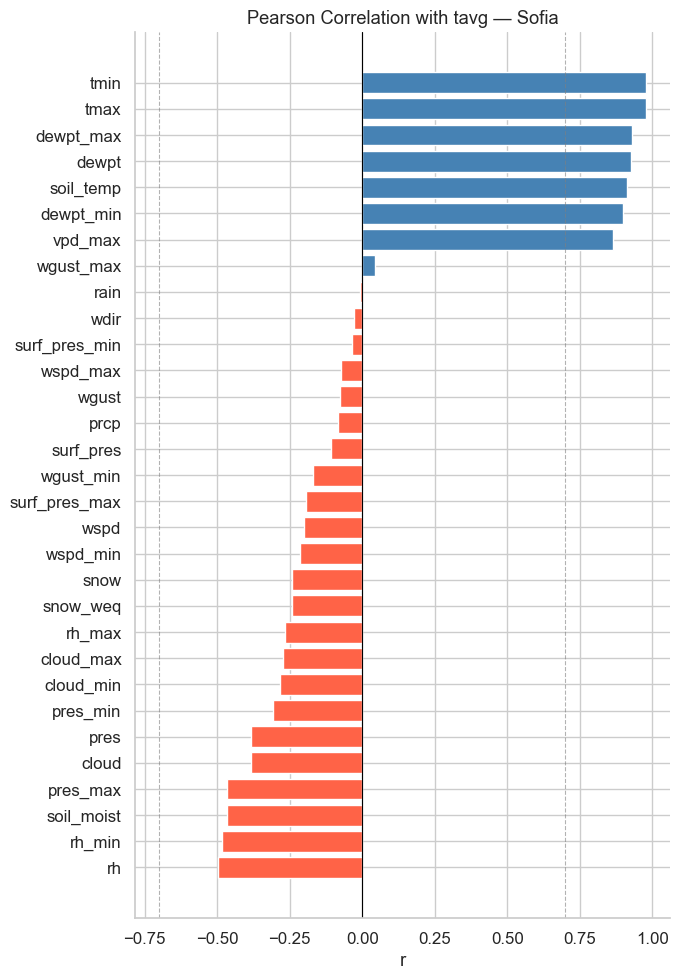

Saved: correlation_tavg_sofia.png

Top positive correlates with tavg:
wgust_max    0.044033
vpd_max      0.864158
dewpt_min    0.899773
soil_temp    0.914207
dewpt        0.927024
dewpt_max    0.931623
tmax         0.978337
tmin         0.978667

Top negative correlates with tavg:
rh           -0.496220
rh_min       -0.483707
soil_moist   -0.467799
pres_max     -0.464534
cloud        -0.384309


In [20]:
corr_city = 'sofia'
df_corr = city_dfs[corr_city].drop(columns=['city'])
corr_with_target = df_corr.corr()['tavg'].drop('tavg').sort_values()

fig, ax = plt.subplots(figsize=(7, 10))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.7,  color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(-0.7, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_title(f'Pearson Correlation with tavg — {corr_city.capitalize()}')
ax.set_xlabel('r')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
#plt.savefig(FIGURES_DIR / f'correlation_tavg_{corr_city}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: correlation_tavg_{corr_city}.png')

print(f'\nTop positive correlates with tavg:')
print(corr_with_target.tail(8).to_string())
print(f'\nTop negative correlates with tavg:')
print(corr_with_target.head(5).to_string())

#### Observations

**Strong positive predictors (r > 0.7):** `soil_temp`, `dewpt`, `tmax`, `tmin`. These variables directly encode the temperature regime `tmax`/`tmin` as same-day bounds, `dewpt` through the moisture-temperature coupling, and `soil_temp` through the deep thermal inertia of the ground. All are high-importance raw features before any lag transformation.

**Strong negative predictors:** `pres` shows strong negative correlation with `tavg`, confirming the critical synoptic signal discussed earlier. Winter anticyclones produce cold, clear days; summer pressure troughs bring warm, unsettled weather. `cloud_min` and `rh_max` are also negatively correlated, consistent with clear-sky nights losing heat to radiation (low overnight cloud = colder minimum temperatures).

**Moderate signal - value is in the lagged form:**
- `soil_moist` shows moderate negative r at t=0 wetter soil is associated with cooler, cloudier conditions. Its primary predictive value is as a lagged feature (5-16 day memory window [2]), not the same-day value shown here.
- `vpd_max` shows moderate positive r, driven almost entirely by warm-season data. In winter it is near zero, so it functions as a warm-season-only predictor.

**Near-zero confirms the circular variable issue:**
- `wdir` shows near-zero r with `tavg` as anticipated. This is **not** evidence of low predictive value, it is evidence that Pearson r is the wrong statistic for a 0–360° circular variable. The sin/cos decomposition is mandatory before evaluating `wdir`'s contribution.
- `prcp` and `rain` show near-zero r with `tavg`, which is expected, precipitation occurrence has no direct linear relationship with daily mean temperature in a temperate climate.

### References

[1] World Meteorological Organization (2018). *Guide to Instruments and Methods of Observation* https://community.wmo.int/...guide-instruments-and-methods-of-observation-wmo-no-8

[2] Wilks, D.S. (2006). *Statistical Methods in the Atmospheric Sciences* (3rd ed.). Academic Press / Elsevier. https://sunandclimate.wordpress.com/wp-content/uploads/2009/05/statistical-methods-in-the-atmospheric-sciences-0127519661.pdf

[3] Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.) https://github.com/ageron/handson-ml3